# K-Nearest Neighbours — Classification and Regression

This notebook implements the KNN workflows described in `notes.md`:

1. `KNeighborsClassifier` on `load_iris` with a K-vs-accuracy sweep (elbow-style, via cross validation) to pick the best K.
2. `KNeighborsRegressor` on `fetch_california_housing`, reporting RMSE and R².

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

%matplotlib inline


## 1) KNN Classification: choosing K via cross validation (Iris)

We sweep $K$ from 1 to 30, evaluate each with 5-fold cross validation accuracy, and plot the resulting elbow-style curve to pick the best $K$. Features are standardized inside a pipeline since KNN is distance-based.

In [2]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

k_range = range(1, 31)
cv_means = []
cv_stds = []

for k in k_range:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipe, X_iris, y_iris, cv=5, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
best_k = list(k_range)[np.argmax(cv_means)]
print(f"Best K by CV accuracy: {best_k} (mean accuracy = {cv_means.max():.4f})")


Best K by CV accuracy: 6 (mean accuracy = 0.9667)


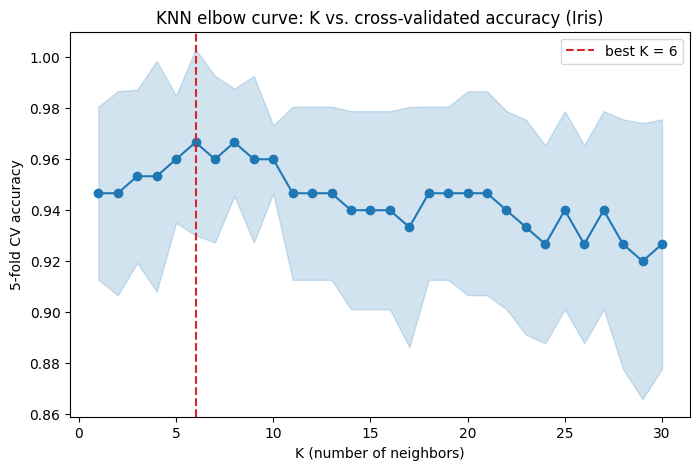

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), cv_means, marker="o", color="tab:blue")
ax.fill_between(list(k_range), cv_means - cv_stds, cv_means + cv_stds, alpha=0.2, color="tab:blue")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"best K = {best_k}")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("KNN elbow curve: K vs. cross-validated accuracy (Iris)")
ax.legend()
plt.show()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

best_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

print(f"Test accuracy with K={best_k}: {accuracy_score(y_test, y_pred):.4f}")


Test accuracy with K=6: 0.9111


## 2) KNN Regression: California Housing

`KNeighborsRegressor` predicts the median house value by averaging the target of the K nearest neighbors in (standardized) feature space. We report RMSE and R² on a held-out test set.

In [5]:
housing = fetch_california_housing()
X_house, y_house = housing.data, housing.target

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

knn_reg = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10))
knn_reg.fit(Xh_train, yh_train)
yh_pred = knn_reg.predict(Xh_test)

rmse = mean_squared_error(yh_test, yh_pred) ** 0.5
r2 = r2_score(yh_test, yh_pred)

print(f"KNeighborsRegressor (K=10) on California Housing:")
print(f"  RMSE: {rmse:.4f}")
print(f"  R^2:  {r2:.4f}")


KNeighborsRegressor (K=10) on California Housing:
  RMSE: 0.6493
  R^2:  0.6783


## Takeaway

- The elbow curve shows CV accuracy rising sharply from K=1 (overfit, noisy) then plateauing/slightly declining for very large K (underfit) — the peak marks the sweet spot in the bias-variance tradeoff.
- For regression, KNN's RMSE/R² on California Housing depend heavily on feature scaling (hence the `StandardScaler` in the pipeline) since geographic and demographic features live on very different numeric ranges.